# Retail Sales Analysis with Python and Pandas

**Author:** Benson M. Merita · Data analyst, Nairobi, Kenya  
**Stack:** Python · NumPy · pandas · Matplotlib  
**Dataset:** *Retail Store Sales: Dirty for Data Cleaning* (Kaggle), 12,575 transactions × 11 columns

I built this notebook while working through the *Python for Data Analysis* programme at Tech Savvy Institute. It walks through the full pandas workflow on a deliberately messy retail dataset: audit the data, clean it, summarise it, reshape and join it, and analyse how sales behave over time.

### Questions the notebook answers

1. How dirty is the data, and how much of it can be recovered instead of thrown away?
2. Which categories, channels and payment methods drive revenue?
3. Do discounts change how much customers spend?
4. How do sales move week to week, and is there a trend or a seasonal pattern?

### Skills shown

| Area | What is demonstrated |
|---|---|
| Data quality | Missing-value audit, rule-based imputation, validation checks |
| Wrangling | Type conversion, filtering, method chaining, `merge` with validation |
| Analysis | `groupby` / `agg` / `transform`, `pivot_table`, `crosstab`, `melt` |
| Time series | `to_datetime`, `.dt`, `resample`, rolling mean and standard deviation |
| Communication | Charts and findings written from the computed numbers |

**To run it:** place `retail_store_sales.csv` next to this notebook (or in a `data/` folder) and run all cells. Requires Python 3.10+, pandas 2.2+, NumPy and Matplotlib.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})
np.random.seed(42)

DATA_PATH = next(p for p in [Path("retail_store_sales.csv"), Path("data/retail_store_sales.csv")] if p.exists())
raw = pd.read_csv(DATA_PATH)
print("pandas", pd.__version__, "| rows, columns:", raw.shape)
raw.head()

pandas 2.3.3 | rows, columns: (12575, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


## 2. NumPy foundations

pandas stores each column as a NumPy array, so three NumPy ideas explain a lot of pandas behaviour: **vectorisation**, **broadcasting** and **views versus copies**.

In [2]:
import time

numbers = np.arange(1_000_000)
as_list = numbers.tolist()

t = time.perf_counter(); sum(x * 2 for x in as_list);  loop_time = time.perf_counter() - t
t = time.perf_counter(); (numbers * 2).sum();          vec_time = time.perf_counter() - t
print(f"Python loop: {loop_time:.4f}s | NumPy vectorised: {vec_time:.4f}s | about {loop_time / vec_time:,.0f}x faster")

Python loop: 0.0773s | NumPy vectorised: 0.0035s | about 22x faster


Vectorised code runs one operation over the whole array in compiled code instead of one Python step per element.

In [3]:
prices = np.array([[1000, 2000, 1500],
                   [800, 1200, 900]])
discount_per_product = np.array([0.90, 0.80, 0.95])   # shape (3,) is stretched across both rows

print(prices * discount_per_product)

[[ 900. 1600. 1425.]
 [ 720.  960.  855.]]


**Broadcasting** applies a smaller array across a larger one without a loop: each product gets its own discount.

In [4]:
original = np.array([10, 20, 30])
view = original[:2]           # a slice is a VIEW: it shares memory with the original
view[0] = 999
print("original after editing the view:", original)

original = np.array([10, 20, 30])
safe = original[:2].copy()    # .copy() gives an independent array
safe[0] = 999
print("original after editing the copy:", original)

original after editing the view: [999  20  30]
original after editing the copy: [10 20 30]


Editing a view changes the source, which is why `.copy()` matters before modifying a slice. pandas has the same trap: filter a DataFrame, then edit the result.

## 3. Data audit

Before changing anything, I check the shape, types, missing values and duplicates.

In [3]:
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_pct": (raw.isna().mean() * 100).round(1),
    "unique": raw.nunique(),
})
print("duplicate rows:", raw.duplicated().sum(), "| duplicate transaction IDs:", raw["Transaction ID"].duplicated().sum())
audit

duplicate rows: 0 | duplicate transaction IDs: 0


,dtype,missing,missing_pct,unique
Transaction ID,object,0,0.0,12575
Customer ID,object,0,0.0,25
Category,object,0,0.0,8
Item,object,1213,9.6,200
Price Per Unit,float64,609,4.8,25
Quantity,float64,604,4.8,10
Total Spent,float64,604,4.8,227
Payment Method,object,0,0.0,3
Location,object,0,0.0,2
Transaction Date,object,0,0.0,1114


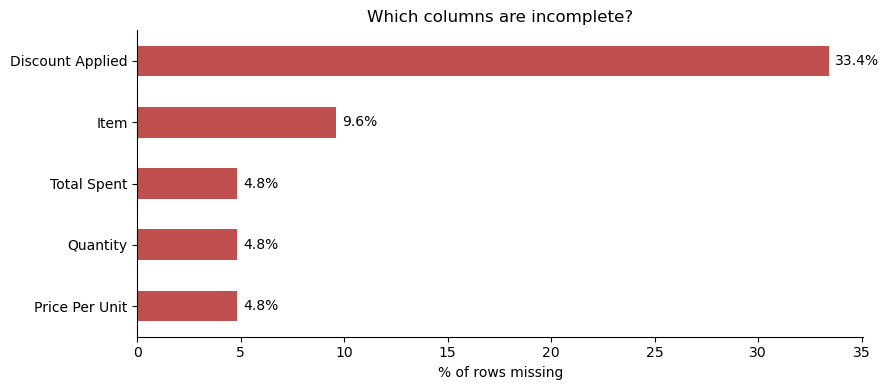

In [4]:
missing = audit.loc[audit["missing"] > 0, "missing_pct"].sort_values()
ax = missing.plot.barh(color="#c0504d")
ax.set_xlabel("% of rows missing")
ax.set_title("Which columns are incomplete?")
for i, v in enumerate(missing):
    ax.text(v + 0.3, i, f"{v}%", va="center")
plt.tight_layout(); plt.show()

Five of eleven columns have gaps, and `Discount Applied` is the worst at about one third. The date, category, payment method, location and IDs are complete.

Two things worth noticing before deciding what to do with the gaps:

- `Discount Applied` is stored as text/objects rather than `bool`, because a boolean column cannot hold "missing".
- Filtering with `== True` silently skips missing rows, so a naive count would under-report.

## 4. Cleaning: recover, don't just drop

The usual quick fix is `dropna()`, but that would delete 1,213 rows with a missing `Item`. Instead I test whether the columns are related, because relationships let me rebuild values with logic rather than guesswork.

Hypotheses to check:

1. `Total Spent = Price Per Unit × Quantity`, so any one of the three can be derived from the other two.
2. Each (`Category`, `Price Per Unit`) pair identifies exactly one `Item`.

In [5]:
complete = raw.dropna(subset=["Price Per Unit", "Quantity", "Total Spent"])
violations = ((complete["Price Per Unit"] * complete["Quantity"] - complete["Total Spent"]).abs() > 0.01).sum()

items_per_key = raw.groupby(["Category", "Price Per Unit"])["Item"].nunique()
print("Rows breaking Price x Quantity = Total:", violations, "of", len(complete))
print("Distinct items per (Category, Price) pair:", items_per_key.unique().tolist())

Rows breaking Price x Quantity = Total: 0 of 11362
Distinct items per (Category, Price) pair: [1]


Both hold without exception, so recovery is safe. The pipeline below rebuilds what it can and leaves everything else alone.

In [6]:
def clean_retail(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # 1. Types and text
    out["Transaction Date"] = pd.to_datetime(out["Transaction Date"], errors="coerce")
    out["Category"] = out["Category"].str.strip()

    # 2. Rebuild numbers from the Price x Quantity = Total rule
    out["Price Per Unit"] = out["Price Per Unit"].fillna(out["Total Spent"] / out["Quantity"])
    out["Quantity"]       = out["Quantity"].fillna(out["Total Spent"] / out["Price Per Unit"])
    out["Total Spent"]    = out["Total Spent"].fillna(out["Price Per Unit"] * out["Quantity"])

    # 3. Rebuild Item from (Category, Price Per Unit)
    lookup = (df.dropna(subset=["Item", "Price Per Unit"])
                .drop_duplicates(["Category", "Price Per Unit"])
                [["Category", "Price Per Unit", "Item"]]
                .rename(columns={"Item": "Item_lookup"}))
    out = out.merge(lookup, on=["Category", "Price Per Unit"], how="left", validate="many_to_one")
    out["Item"] = out["Item"].fillna(out["Item_lookup"])
    out = out.drop(columns="Item_lookup")

    # 4. Keep "not recorded" as its own value instead of pretending it means "no discount"
    out["Discount Applied"] = out["Discount Applied"].map({True: "Yes", False: "No"}).fillna("Not recorded")
    return out

clean = clean_retail(raw)

cols = ["Item", "Price Per Unit", "Quantity", "Total Spent"]
recovery = pd.DataFrame({"missing before": raw[cols].isna().sum(), "missing after": clean[cols].isna().sum()})
recovery["recovered"] = recovery["missing before"] - recovery["missing after"]
recovery

,missing before,missing after,recovered
Item,1213,0,1213
Price Per Unit,609,0,609
Quantity,604,604,0
Total Spent,604,604,0


In [7]:
# Validation: the rebuilt data must not break the rule, and no rows may be gained or lost
check = clean.dropna(subset=["Price Per Unit", "Quantity", "Total Spent"])
assert len(clean) == len(raw)
assert ((check["Price Per Unit"] * check["Quantity"] - check["Total Spent"]).abs() < 0.01).all()

both_missing = (raw["Quantity"].isna() & raw["Total Spent"].isna()).sum()
print("Rows missing Quantity AND Total Spent together:", both_missing)
print("Rows with a known Total Spent (used for all revenue analysis):", clean["Total Spent"].notna().sum())

Rows missing Quantity AND Total Spent together: 604
Rows with a known Total Spent (used for all revenue analysis): 11971


`Price Per Unit` and `Item` are now complete. `Quantity` and `Total Spent` still have gaps, and these are the **same rows**: when both are missing, only the price is left and there is nothing to derive them from. I leave those rows out of revenue calculations instead of inventing values. Every revenue figure below is therefore a slight **under-estimate** of true sales.

In [8]:
sales = clean.dropna(subset=["Total Spent"]).copy()
print(sales.shape)
sales.head()

(11971, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,Yes
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,Yes
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,No
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,Not recorded
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,No


## 5. Aggregation: where does revenue come from?

In [9]:
kpis = {
    "Total revenue": f"{sales['Total Spent'].sum():,.0f}",
    "Transactions": f"{len(sales):,}",
    "Average transaction": f"{sales['Total Spent'].mean():,.2f}",
    "Median transaction": f"{sales['Total Spent'].median():,.2f}",
    "Customers": sales["Customer ID"].nunique(),
}
pd.Series(kpis, name="value").to_frame()

,value
Total revenue,"1,552,071"
Transactions,"11,971"
Average transaction,129.65
Median transaction,108.50
Customers,25


In [10]:
category_summary = (
    sales.groupby("Category")
    .agg(revenue=("Total Spent", "sum"),
         avg_sale=("Total Spent", "mean"),
         transactions=("Transaction ID", "count"),
         units=("Quantity", "sum"))
    .assign(share=lambda d: (d["revenue"] / d["revenue"].sum() * 100).round(1))
    .sort_values("revenue", ascending=False)
)
category_summary.round(1)

,revenue,avg_sale,transactions,units,share
Category,,,,,
Butchers,208118.0,139.1,1496,8206.0,13.4
Electric household essentials,203813.5,134.4,1516,8309.0,13.1
Beverages,197047.5,131.7,1496,8358.0,12.7
Furniture,195310.0,128.1,1525,8462.0,12.6
Food,194812.0,129.3,1507,8387.0,12.6
Computers and electric accessories,190692.5,129.1,1477,8272.0,12.3
Patisserie,182165.5,126.4,1441,7943.0,11.7
Milk Products,180112.0,119.0,1513,8339.0,11.6


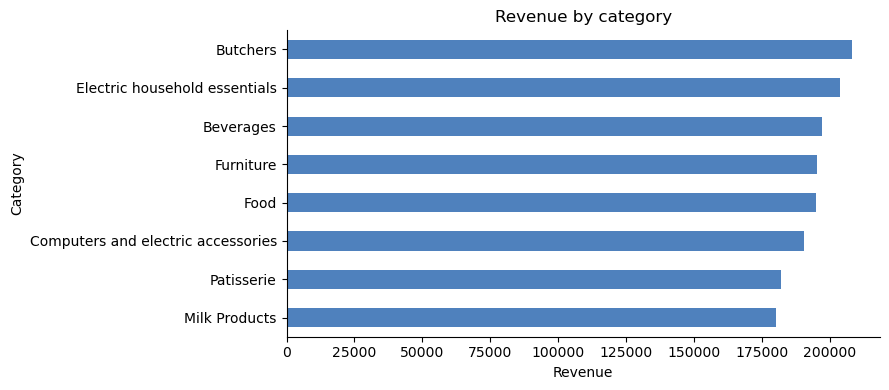

In [11]:
ax = category_summary["revenue"].sort_values().plot.barh(color="#4f81bd")
ax.set_xlabel("Revenue")
ax.set_title("Revenue by category")
plt.tight_layout(); plt.show()

`groupby` splits the rows into groups, `agg` calculates several named measures per group, and `assign` adds a derived column. Named aggregation keeps the output columns readable.

In [12]:
channel = sales.groupby("Location").agg(revenue=("Total Spent", "sum"), avg_sale=("Total Spent", "mean"), transactions=("Total Spent", "count"))
payment = sales.groupby("Payment Method").agg(revenue=("Total Spent", "sum"), avg_sale=("Total Spent", "mean"), transactions=("Total Spent", "count"))
display(channel.round(1)); display(payment.round(1))

,revenue,avg_sale,transactions
Location,,,
In-store,760670.0,128.9,5903
Online,791401.0,130.4,6068


,revenue,avg_sale,transactions
Payment Method,,,
Cash,537710.0,131.1,4103
Credit Card,507082.0,129.1,3927
Digital Wallet,507279.0,128.7,3941


### Do discounts change spending?

In [13]:
discount_effect = (
    sales.groupby("Discount Applied")["Total Spent"]
    .agg(transactions="count", average_spend="mean", median_spend="median")
    .round(2)
)
discount_effect

,transactions,average_spend,median_spend
Discount Applied,,,
No,3964,129.95,109.5
Not recorded,3988,128.51,105.0
Yes,4019,130.49,109.5


Average spend is almost identical whether or not a discount was recorded, so in this data a discount does not visibly lift the size of a transaction. The `Not recorded` group behaves like the others, which supports keeping it separate instead of assuming it means "no discount".

In [14]:
# transform: put each category's average beside every row without collapsing the table
sales["category_avg"] = sales.groupby("Category")["Total Spent"].transform("mean")
sales["above_category_avg"] = sales["Total Spent"] > sales["category_avg"]
print("Share of transactions above their category average:", round(sales["above_category_avg"].mean(), 3))

Share of transactions above their category average: 0.413


## 6. Reshaping: pivot, crosstab, melt

In [15]:
rev_pivot = pd.pivot_table(sales, values="Total Spent", index="Category", columns="Location",
                           aggfunc="sum", margins=True, margins_name="Total")
rev_pivot.round(0)

Location,In-store,Online,Total
Category,,,
Beverages,98026.0,99022.0,197048.0
Butchers,101777.0,106341.0,208118.0
Computers and electric accessories,87324.0,103369.0,190692.0
Electric household essentials,97778.0,106035.0,203814.0
Food,95926.0,98886.0,194812.0
Furniture,99611.0,95699.0,195310.0
Milk Products,88813.0,91299.0,180112.0
Patisserie,91415.0,90750.0,182166.0
Total,760670.0,791401.0,1552071.0


In [16]:
pay_mix = (pd.crosstab(sales["Location"], sales["Payment Method"], normalize="index") * 100).round(1)
pay_mix

Payment Method,Cash,Credit Card,Digital Wallet
Location,,,
In-store,34.4,32.5,33.1
Online,34.1,33.1,32.8


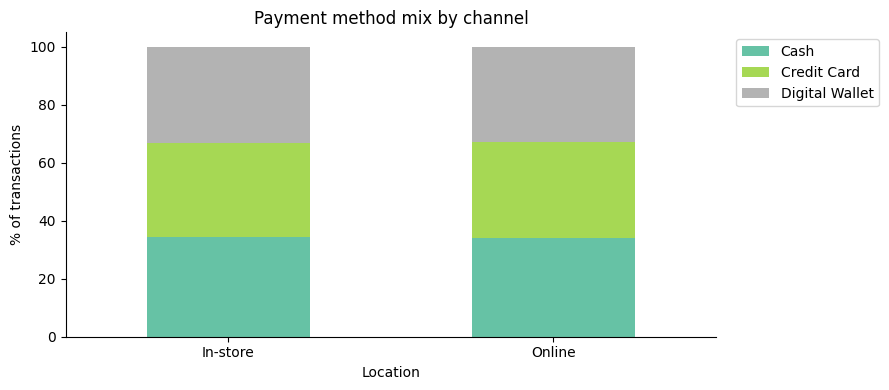

In [19]:
ax = pay_mix.plot.bar(stacked=True, rot=0, colormap="Set2")
ax.set_ylabel("% of transactions")
ax.set_title("Payment method mix by channel")
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

In [17]:
# melt: wide -> long, the shape most plotting and BI tools prefer
long_form = (rev_pivot.drop(index="Total", columns="Total").reset_index()
             .melt(id_vars="Category", var_name="Location", value_name="Revenue"))
long_form.head(6)

,Category,Location,Revenue
0,Beverages,In-store,98026.0
1,Butchers,In-store,101777.0
2,Computers and electric accessories,In-store,87323.5
3,Electric household essentials,In-store,97778.5
4,Food,In-store,95926.0
5,Furniture,In-store,99611.0


`pivot_table` summarises numbers across two dimensions, `crosstab` counts combinations (here as row percentages), and `melt` reverses a pivot into one row per observation.

## 7. Combining tables: customer segments

I build a customer-level table, label each customer as Low, Mid or High spender by tercile, and join that back onto the transactions. `validate="many_to_one"` makes pandas stop if the key is not unique on the lookup side.

In [18]:
customers = (sales.groupby("Customer ID")
             .agg(total_spent=("Total Spent", "sum"), transactions=("Total Spent", "count"))
             .reset_index())
customers["segment"] = pd.qcut(customers["total_spent"], 3, labels=["Low", "Mid", "High"])

merged = sales.merge(customers[["Customer ID", "segment"]], on="Customer ID", how="left", validate="many_to_one", indicator=True)
assert (merged["_merge"] == "both").all() and len(merged) == len(sales)

segment_summary = merged.groupby("segment", observed=True).agg(customers=("Customer ID", "nunique"),
                                                               revenue=("Total Spent", "sum"),
                                                               avg_sale=("Total Spent", "mean")).round(1)
segment_summary

,customers,revenue,avg_sale
segment,,,
Low,9,534298.5,127.5
Mid,8,493607.0,130.8
High,8,524165.5,130.8


The merge check confirms every transaction found its customer and no rows were duplicated. Note the spread: the customer base is small (25 customers) and evenly matched, so segments differ only modestly.

## 8. Time series

Convert dates to `datetime`, index by date, then use `resample` to change frequency and `rolling` to smooth. The first and last weeks are partial (the data starts on a Saturday and ends mid-week), so they are excluded from the trend statistics.

In [19]:
ts = sales.set_index("Transaction Date").sort_index()["Total Spent"]

weekly = ts.resample("W").sum()
full_weeks = weekly.iloc[1:-1]
roll_mean = full_weeks.rolling(4).mean()
roll_std = full_weeks.rolling(4).std()

print("date range:", ts.index.min().date(), "to", ts.index.max().date(), "| full weeks:", len(full_weeks))
pd.DataFrame({"weekly": full_weeks, "rolling_mean_4w": roll_mean, "rolling_std_4w": roll_std}).describe().round(0)

date range: 2022-01-01 to 2025-01-18 | full weeks: 158


,weekly,rolling_mean_4w,rolling_std_4w
count,158.0,155.0,155.0
mean,9762.0,9735.0,1301.0
std,1477.0,814.0,522.0
min,5519.0,8039.0,265.0
25%,8758.0,9224.0,904.0
50%,9703.0,9752.0,1296.0
75%,10803.0,10264.0,1651.0
max,13441.0,12242.0,2689.0


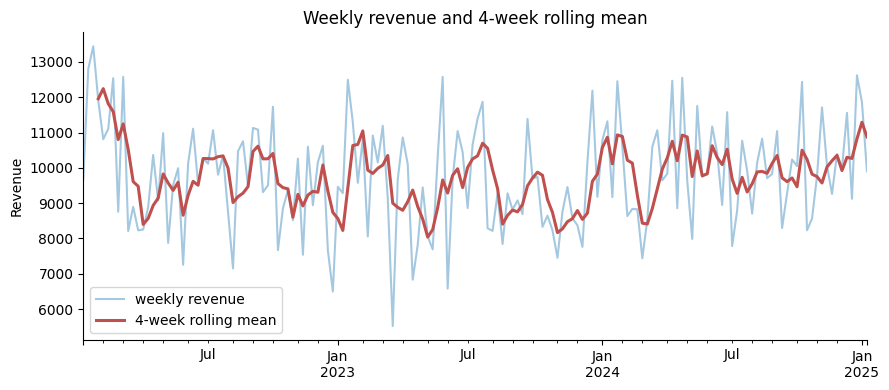

In [23]:
fig, ax = plt.subplots()
full_weeks.plot(ax=ax, alpha=0.4, label="weekly revenue")
roll_mean.plot(ax=ax, linewidth=2.2, color="#c0504d", label="4-week rolling mean")
ax.set_title("Weekly revenue and 4-week rolling mean")
ax.set_xlabel(""); ax.set_ylabel("Revenue"); ax.legend()
plt.tight_layout(); plt.show()

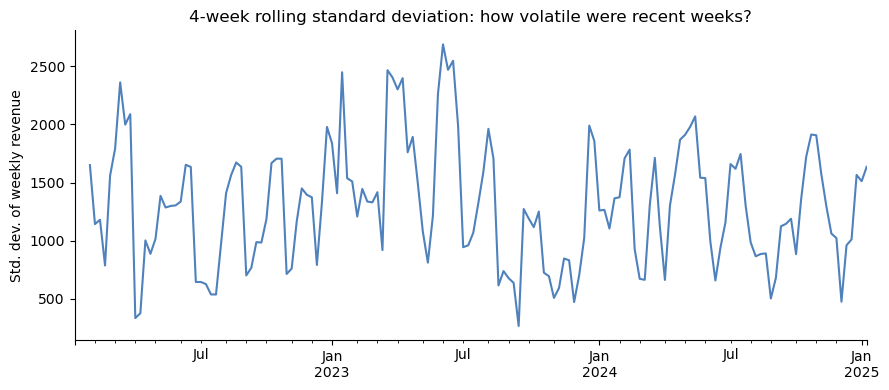

In [20]:
fig, ax = plt.subplots()
roll_std.plot(ax=ax, color="#4f81bd")
ax.set_title("4-week rolling standard deviation: how volatile were recent weeks?")
ax.set_xlabel(""); ax.set_ylabel("Std. dev. of weekly revenue")
plt.tight_layout(); plt.show()

`resample("W")` changes the frequency (daily rows become weekly rows). `rolling(4)` slides a four-week window along the weekly series, so the mean smooths noise and the standard deviation shows volatility.

In [21]:
# Seasonality: average DAILY revenue per calendar month, by year (daily average avoids the month-length effect)
daily = ts.resample("D").sum()
by_month = daily.groupby([daily.index.year, daily.index.month]).mean().unstack(0).round(0)
by_month.index.name = "month"
by_month

Transaction Date,2022,2023,2024,2025
month,,,,
1,1707.0,1550.0,1545.0,1419.0
2,1547.0,1401.0,1281.0,NaN
3,1322.0,1243.0,1383.0,NaN
4,1348.0,1297.0,1542.0,NaN
5,1302.0,1306.0,1412.0,NaN
6,1419.0,1416.0,1491.0,NaN
7,1435.0,1472.0,1336.0,NaN
8,1333.0,1245.0,1399.0,NaN
9,1537.0,1369.0,1405.0,NaN


In [22]:
dow = ts.groupby(ts.index.day_name()).agg(["sum", "mean"]).reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]).round(1)
dow

,sum,mean
Transaction Date,,
Monday,213090.5,125.6
Tuesday,219650.0,129.5
Wednesday,216982.0,126.8
Thursday,219380.5,129.3
Friday,232786.0,134.6
Saturday,224191.0,131.5
Sunday,225991.0,130.2


## 9. Findings

In [23]:
top_cat = category_summary["share"].idxmax(); low_cat = category_summary["share"].idxmin()
spread = category_summary["share"].max() - category_summary["share"].min()

chan_gap = channel["revenue"].max() / channel["revenue"].min() - 1
avg_gap  = payment["avg_sale"].max() / payment["avg_sale"].min() - 1
d_yes, d_no = discount_effect.loc["Yes", "average_spend"], discount_effect.loc["No", "average_spend"]

slope, _ = np.polyfit(np.arange(len(full_weeks)), full_weeks.values, 1)
drift = slope * len(full_weeks) / full_weeks.mean()
cv = full_weeks.std() / full_weeks.mean()

full_years = [y for y in by_month.columns if by_month[y].notna().sum() == 12]      # 2025 has only January, so it cannot be ranked
jan_ranks = {y: int(by_month[y].rank(ascending=False).loc[1]) for y in full_years}
jan_txt = ", ".join(f"#{r} of 12 in {y}" for y, r in jan_ranks.items())

miss_total = raw["Total Spent"].isna().sum()
saved = int(recovery.loc["Item", "recovered"])

display(Markdown(f'''
1. **Revenue is spread very evenly across categories.** {top_cat} leads with {category_summary["share"].max()}% and {low_cat} trails with {category_summary["share"].min()}%, a spread of only {spread:.1f} percentage points. No single category dominates, so the business is not dependent on one line.
2. **Channel and payment method barely matter.** Online revenue is within {chan_gap:.1%} of in-store, and average transaction size differs by only {avg_gap:.1%} across payment methods. Customers behave alike wherever and however they pay.
3. **Discounts show no lift in this data.** Average spend is {d_yes:,.1f} with a recorded discount versus {d_no:,.1f} without ({d_yes / d_no - 1:+.1%}). If the business runs discounts to raise basket size, this data does not show it working.
4. **Weekly revenue is stable, not trending.** A typical week varies by about {cv:.0%} around its average, and a fitted line moves only {drift:+.1%} over three years. Rolling averages swing up and down without a lasting direction.
5. **January is consistently one of the strongest months.** Ranked by daily average revenue across the full years, January placed {jan_txt}. That points to a new-year buying pattern worth planning stock and staff around, although three years is a short history for calling it seasonality.
6. **Data quality was fixable.** Rule-based recovery restored all {saved:,} missing items and every missing price, keeping rows that `dropna()` would have deleted. {miss_total:,} transactions still lack a total and were excluded, so absolute revenue is slightly understated.
'''))


1. **Revenue is spread very evenly across categories.** Butchers leads with 13.4% and Milk Products trails with 11.6%, a spread of only 1.8 percentage points. No single category dominates, so the business is not dependent on one line.
2. **Channel and payment method barely matter.** Online revenue is within 4.0% of in-store, and average transaction size differs by only 1.8% across payment methods. Customers behave alike wherever and however they pay.
3. **Discounts show no lift in this data.** Average spend is 130.5 with a recorded discount versus 129.9 without (+0.4%). If the business runs discounts to raise basket size, this data does not show it working.
4. **Weekly revenue is stable, not trending.** A typical week varies by about 15% around its average, and a fitted line moves only +1.4% over three years. Rolling averages swing up and down without a lasting direction.
5. **January is consistently one of the strongest months.** Ranked by daily average revenue across the full years, January placed #1 of 12 in 2022, #1 of 12 in 2023, #2 of 12 in 2024. That points to a new-year buying pattern worth planning stock and staff around, although three years is a short history for calling it seasonality.
6. **Data quality was fixable.** Rule-based recovery restored all 1,213 missing items and every missing price, keeping rows that `dropna()` would have deleted. 604 transactions still lack a total and were excluded, so absolute revenue is slightly understated.


### Limitations

- The dataset is built for practising data cleaning, so its business patterns are mild. Real retail data would normally show stronger differences between categories, channels and customers.
- The customer base is only 25 IDs, which limits any customer segmentation.
- The data has no cost or margin column, so revenue is the only performance measure available; higher revenue is not the same as higher profit.
- Differences of a few percent were read as "no difference" by eye. A next step would be a proper significance test.

### What I learned

- Check relationships between columns before dropping data; a simple business rule recovered more than a thousand rows.
- Missing values fail silently in filters and counts, so audit them first.
- Choose the operation from the question: `groupby` for summaries, `pivot_table` for two-way tables, `merge` for lookups, `resample` and `rolling` for time.

### Next steps

Extend the analysis with statistical tests, build a Power BI dashboard on the cleaned data, and repeat the workflow on a SQL-sourced dataset.

---
*Built as a learning project during the Tech Savvy Institute Python for Data Analysis programme. Dataset: Kaggle, Retail Store Sales: Dirty for Data Cleaning.*